# Setup

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

sys.path.append('..')
from src.config import SEMEVAL_TRAIN_PATH, SEMEVAL_TEST_PATH, AMAZON_HINDI_PATH
from src.data.lang_detect import detect_language
from src.data.transliterate import transliterate
from src.data.preprocess import clean

# Load Data

In [2]:
def load_jsonl(path):
    data = []
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                data.append(json.loads(line))
    return data

semeval_train = load_jsonl(SEMEVAL_TRAIN_PATH)
semeval_test = load_jsonl(SEMEVAL_TEST_PATH)
amazon_hindi = load_jsonl(AMAZON_HINDI_PATH)

print(f"SemEval Train Samples: {len(semeval_train)}")
print(f"SemEval Test Samples: {len(semeval_test)}")
print(f"Amazon Hindi Samples: {len(amazon_hindi)}")

SemEval Train Samples: 3501
SemEval Test Samples: 1028
Amazon Hindi Samples: 1000


# Language Distribution

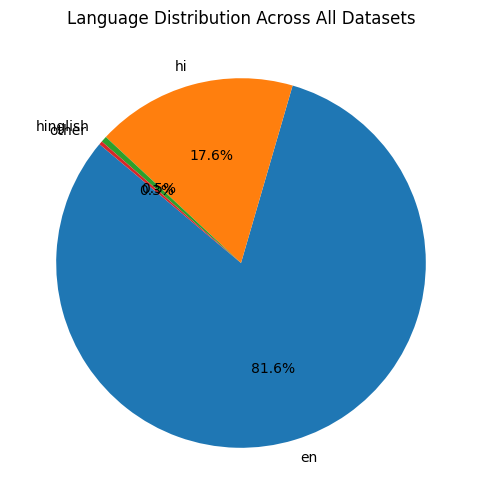

In [3]:
all_data = semeval_train + semeval_test + amazon_hindi
languages = [x['language'] for x in all_data]
lang_counts = pd.Series(languages).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Language Distribution Across All Datasets')
plt.show()

# Sentiment Class Distribution per Dataset

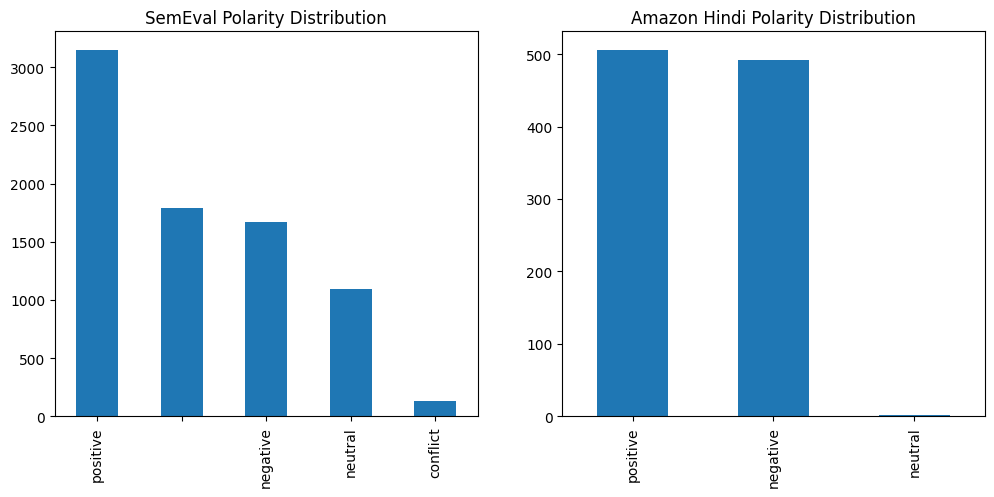

In [4]:
semeval_sentiments = []
for s in semeval_train + semeval_test:
    for aspect in s['aspect_terms']:
        semeval_sentiments.append(aspect['polarity'])
        
hindi_sentiments = [x.get('label') for x in amazon_hindi if x.get('label')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(semeval_sentiments).value_counts().plot(kind='bar', ax=ax1, title='SemEval Polarity Distribution')
pd.Series(hindi_sentiments).value_counts().plot(kind='bar', ax=ax2, title='Amazon Hindi Polarity Distribution')
plt.show()

# Average Review Length by Language

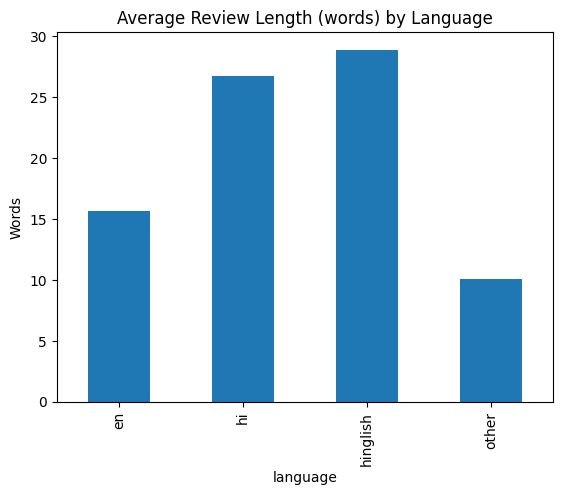

In [5]:
df = pd.DataFrame(all_data)
df['length'] = df['text'].apply(lambda x: len(x.split()))
avg_len = df.groupby('language')['length'].mean()
avg_len.plot(kind='bar', title='Average Review Length (words) by Language', ylabel='Words')
plt.show()

# Aspect Term Analysis

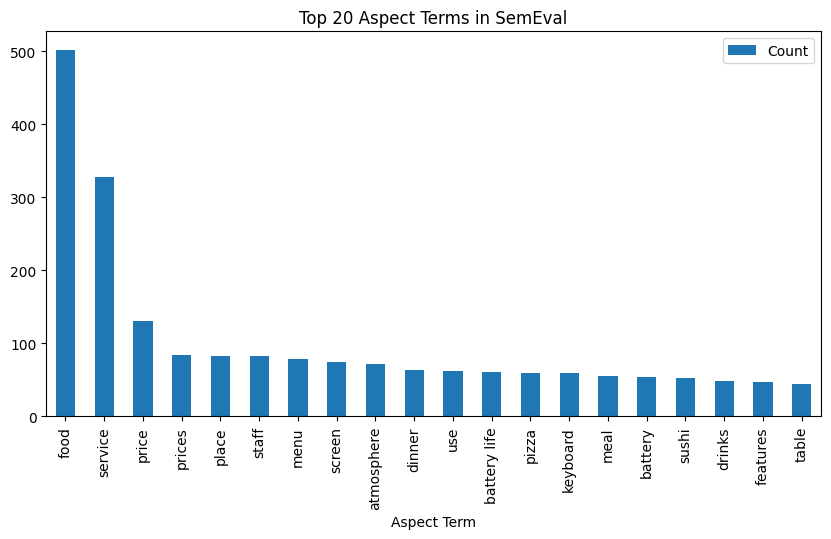

In [6]:
aspects = []
for s in semeval_train + semeval_test:
    for asp in s['aspect_terms']:
        aspects.append(asp['term'])

top_20 = Counter(aspects).most_common(20)
top_20_df = pd.DataFrame(top_20, columns=['Aspect Term', 'Count'])
top_20_df.set_index('Aspect Term').plot(kind='bar', figsize=(10, 5), title='Top 20 Aspect Terms in SemEval')
plt.show()

# Sample Hinglish Reviews Transliteration

In [7]:
hinglish_samples = [
    "Phone bahut badhiya hai, लेकिन battery is bad.",
    "I love this! मुझे यह पसंद है",
    "Screen quality accha hai but sound thik thak hai.",
    "Camera theek hai, photo accha aata hai.",
    "Service bahut slow hai, completely disappointed."
]

for text in hinglish_samples:
    print(f"Original: {text}")
    print(f"Transliterated: {transliterate(text, 'hinglish')}")
    print("-" * 50)

Original: Phone bahut badhiya hai, लेकिन battery is bad.
Transliterated: Phone bahut badhiya hai, ेिन battery is bad.
--------------------------------------------------
Original: I love this! मुझे यह पसंद है
Transliterated: I love this! ुे यह पसंद ै
--------------------------------------------------
Original: Screen quality accha hai but sound thik thak hai.
Transliterated: Screen quality achha hai but sound thik thak hai.
--------------------------------------------------
Original: Camera theek hai, photo accha aata hai.
Transliterated: Camera theek hai, photo achha aata hai.
--------------------------------------------------
Original: Service bahut slow hai, completely disappointed.
Transliterated: Service bahut slow hai, completely disappointed.
--------------------------------------------------
